In [ ]:
"""
The data is not included. The code had been run so the graph and result should be readily visible. 
Question & problems, contact
cobb.liang.24@ucl.ac.uk
Jiaming Liang
2026
"""

In [1]:
import h5py
import scipy.io
f = scipy.io.loadmat('2023_07_07/2023_07_07_2023_07_25/plane_all_matched_3sessions.mat')
print(list(f.keys()))
#print(list(f['plane_all_decon_re'][5]))
x = f['plane_all_decon_re']

n_trials = 239
n_neurons = 1747
n_bins_per_trial = 47
n_trials2 = 308
n_neurons2 = 1747
n_bins_per_trial2 = 47


['__header__', '__version__', '__globals__', 'nplanes', 'plane_all', 'plane_all_decon_re', 'real_roi_id', 'total_roi_id']


In [2]:
#train x[0-1746,0][:] left
# x[0-1746,1][:] right
#n_trials = 103 l + 136 r
#n_neurons = 1747
#n_bins_per_trial = 47
#make（239，1747，47）matrix
#reshape (239,1747*47)
#make decision matrix：[239]
from sklearn import linear_model
import numpy as np
datama = np.zeros((239,1747,47))
for i in range(103):
    for m in range(1747):
        for y in range(47):
            datama[i, m, y] = x[m, 0][i,y]

# 右Right trials
for i in range(136):
    for m in range(1747):
        for y in range(47):
            datama[103+i, m, y] = x[m, 1][i,y]    
#for 
print(datama[0,0,0])


0.15808027982711792


In [3]:
#make decision result matrix
decision = np.concatenate([np.ones(103),np.zeros(136)])

reshapedata = np.reshape(datama, (n_trials,-1))

In [4]:
log_reg = linear_model.LogisticRegression(penalty='l2', solver = 'lbfgs',max_iter = 1000)

log_reg.fit(reshapedata,decision)
print(log_reg.score(reshapedata,decision))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


1.0


(1747, 47)


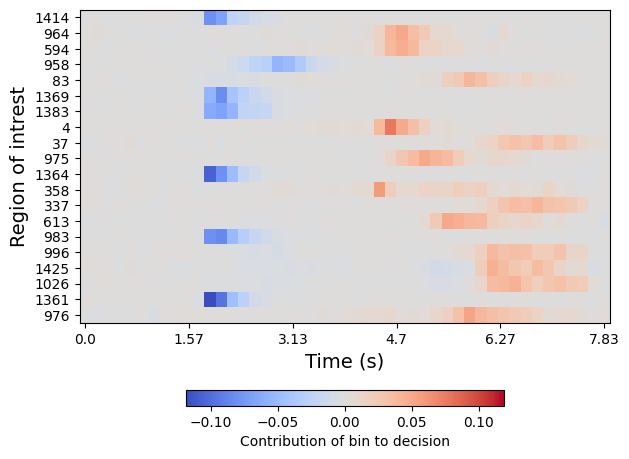

In [5]:
#find main contributors
from matplotlib import pyplot as plt
coefficients = log_reg.coef_.reshape(n_neurons, n_bins_per_trial)
print(coefficients.shape)  
idx = np.argsort(np.abs(coefficients).mean(axis=1))[-20:]


plt.figure
plt.imshow(coefficients[idx,:],aspect='auto', cmap = 'coolwarm', vmin = -np.max(coefficients), 
                                              vmax = np.max(coefficients))
plt.ylabel("Region of intrest", fontsize = 14)
plt.xlabel("Time (s)", fontsize = 14)
plt.yticks(range(20), idx)
plt.xticks(
    ticks=np.linspace(0, 46, 6),
    labels=np.round(np.linspace(0, 47*(1/6), 6), 2)  # 秒
)
plt.colorbar(orientation = 'horizontal', shrink = .6, 
               label="Contribution of bin to decision")
plt.tight_layout()
plt.show()
  

In [ ]:
#Generalized to another session
f2 = scipy.io.loadmat('2023_07_25/2023_07_07_2023_07_25/plane_all_matched_3sessions.mat')
x2 = f2['plane_all_decon_re']

datama2 = np.zeros((308,1747,47))
for i in range(153):
    for m in range(1747):
        for y in range(47):
            datama2[i, m, y] = x2[m, 0][i,y]

# R右 trials
for i in range(155):
    for m in range(1747):
        for y in range(47):
            datama2[153+i, m, y] = x2[m, 1][i,y]    
decision2 = np.concatenate([np.ones(153),np.zeros(155)])

reshapedata2 = np.reshape(datama2, (n_trials2,-1))

print(log_reg.score(reshapedata2,decision2))

['__header__', '__version__', '__globals__', 'nplanes', 'plane_all', 'plane_all_decon_re', 'real_roi_id', 'total_roi_id']
0.9967532467532467


(308, 2)
(308,)


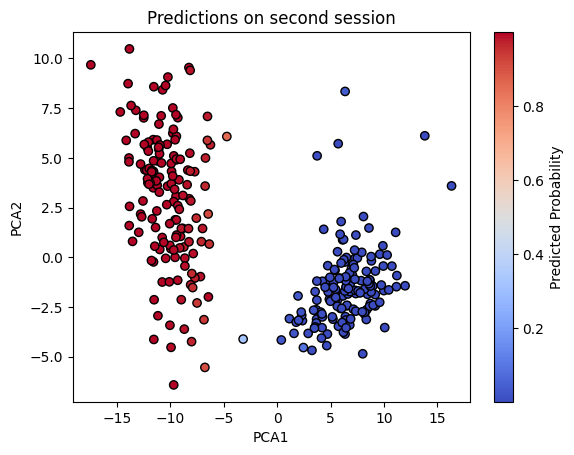

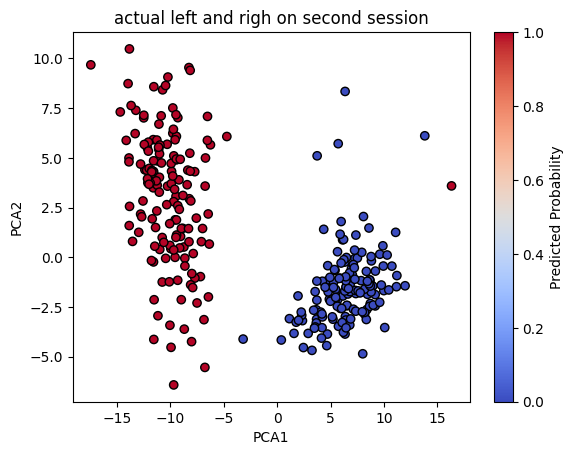

In [7]:
#prediction result in PCA field
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_test_pca = PCA(n_components=2).fit(reshapedata).transform(reshapedata2)
y_prob = log_reg.predict_proba(reshapedata2)[:,1]
print(X_test_pca.shape)
print(y_prob.shape)
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=y_prob, cmap='coolwarm', edgecolor='k')
plt.colorbar(label='Predicted Probability')
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Predictions on second session")
plt.show()


plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=decision2, cmap='coolwarm', edgecolor='k')
plt.colorbar(label='Predicted Probability')
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("actual left and righ on second session")
plt.show()

Text(0, 0.5, 'Accuracy')

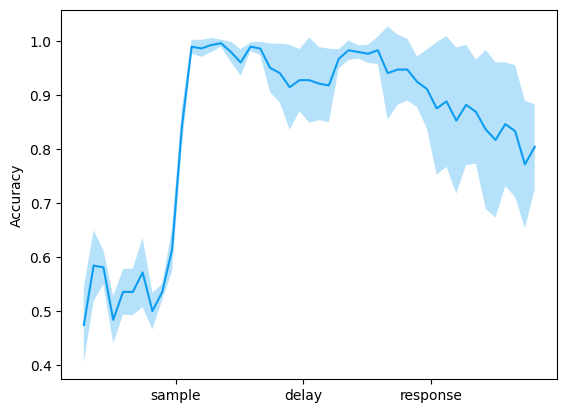

In [ ]:
#decoding and timecourse
timedatama = datama[:,:,0]
from sklearn.model_selection import cross_val_score

y_probtime = np.zeros(47)
y_std = np.zeros(47)

for time in range(47):
    X = np.reshape(datama[:,:,time], (n_trials, -1))
    y = decision
    timedatama = datama[:,:,time]
    reshapedatatime = np.reshape(timedatama, (n_trials,-1))
    timedatama2 = datama2[:,:,time]
    reshapedatatime2 = np.reshape(timedatama2, (n_trials2, -1))
    log_regtime = linear_model.LogisticRegression(solver='lbfgs', max_iter=1000)
    scores = cross_val_score(log_regtime, reshapedatatime2, decision2, cv=5)
    y_probtime[time] = scores.mean()  # average accuracy
    y_std[time] = scores.std()

timex = np.arange(47)
plt.plot(timex, y_probtime,color="#0D9DF0")
plt.fill_between(timex, y_probtime - y_std, y_probtime + y_std, color="#0D9DF0", alpha=0.3, edgecolor="none")
plt.xticks((9.4,22.4,35.4),('sample','delay','response'))
plt.ylabel("Accuracy")

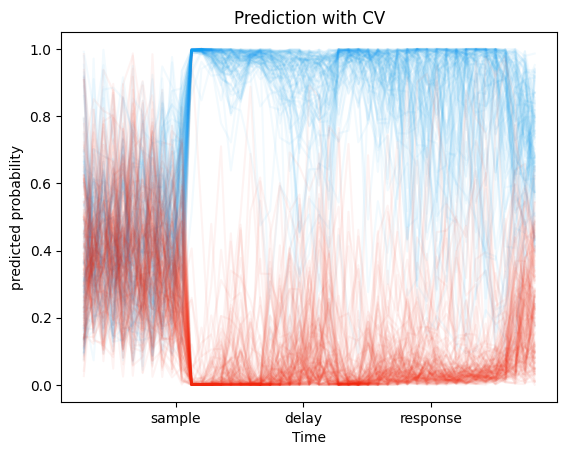

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

y_probtime = np.zeros((239, 47))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for time in range(47):
    X = np.reshape(datama[:,:,time], (n_trials, -1))
    y = decision
    log_regtime = LogisticRegression(solver='lbfgs', max_iter=1000)

    # out-of-fold 预测概率
    y_probtime[:,time] = cross_val_predict(
        log_regtime, X, y, cv=skf, method='predict_proba'
    )[:,1]

timex = np.arange(47)

for trialnnl in range(103):
    plt.plot(timex, y_probtime[trialnnl,:], alpha=0.05, color="#0D9DF0")
for trialnnr in range(103,239):
    plt.plot(timex, y_probtime[trialnnr,:], alpha=0.05, color="#F0270D")

plt.xlabel("Time")
plt.ylabel("predicted probability")
plt.xticks([9.4,22.4,35.4], ['sample','delay','response'])
plt.title("Prediction with CV")
plt.show()